In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [4]:
df.shape

(3803, 23)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


**PRICE**

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/2372346179.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['price'])


<Axes: ylabel='Density'>

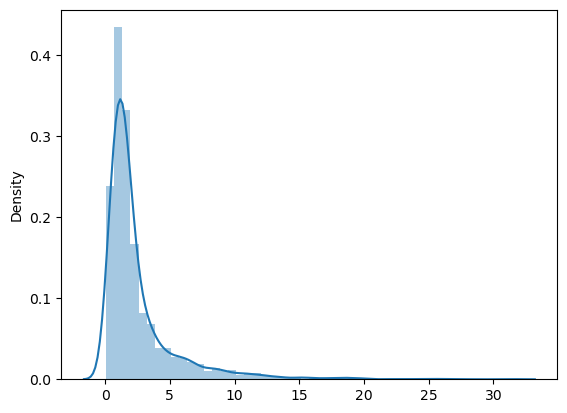

In [6]:
sns.distplot(x=df['price'])

<Axes: xlabel='price'>

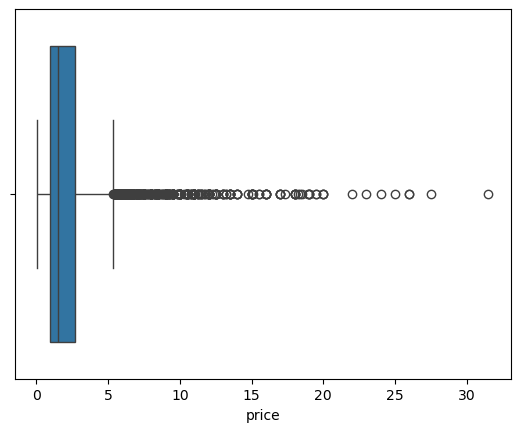

In [7]:
sns.boxplot(x=df['price'])

In [8]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

num_outliers = outliers.shape[0]
outlier_price_stats = outliers['price'].describe()
num_outliers,outlier_price_stats

(432,
 count    432.000000
 mean       9.196157
 std        4.061291
 min        5.350000
 25%        6.400000
 50%        8.000000
 75%       10.607500
 max       31.500000
 Name: price, dtype: float64)

In [9]:
df.shape

(3803, 23)

In [10]:
# There are some genuine outliers but there are some data errors as well

**PRICE_PER_SQFT**

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

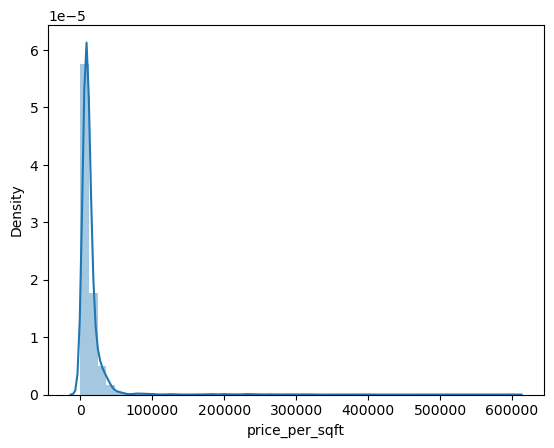

In [11]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

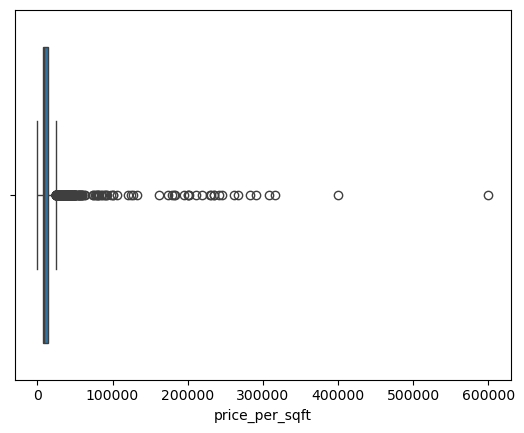

In [12]:
sns.boxplot(x=df['price_per_sqft'])

In [13]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outlier_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft']>upper_bound)]

outlier_shape = outlier_sqft.shape[0]
outlier_sqft_stats = outlier_sqft['price_per_sqft'].describe()

outlier_shape,outlier_sqft_stats

(367,
 count       367.000000
 mean      52115.435967
 std       60746.225927
 min       24202.000000
 25%       27778.000000
 50%       33333.000000
 75%       41790.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [14]:
df.shape

(3803, 23)

In [15]:
outlier_sqft['area']

10      1350.0
19      1440.0
25      3240.0
26      2475.0
39      2160.0
         ...  
3768    1449.0
3774      50.0
3791    2430.0
3794    3042.0
3801    5490.0
Name: area, Length: 367, dtype: float64

In [16]:
outlier_sqft['area'] = outlier_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/2244418497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_sqft['area'] = outlier_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [17]:
outlier_sqft['price_per_sqft'] = round((outlier_sqft['price']*10000000)/outlier_sqft['area'])

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/58626075.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_sqft['price_per_sqft'] = round((outlier_sqft['price']*10000000)/outlier_sqft['area'])


In [18]:
outlier_sqft['price_per_sqft'].describe()

count      367.000000
mean     29160.735695
std      12308.413881
min       2689.000000
25%      25051.500000
50%      29630.000000
75%      35489.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [19]:
df.update(outlier_sqft)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/2653482184.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

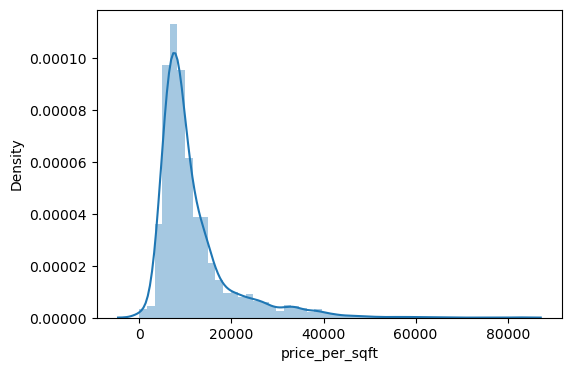

In [20]:
plt.figure(figsize=(6,4))
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

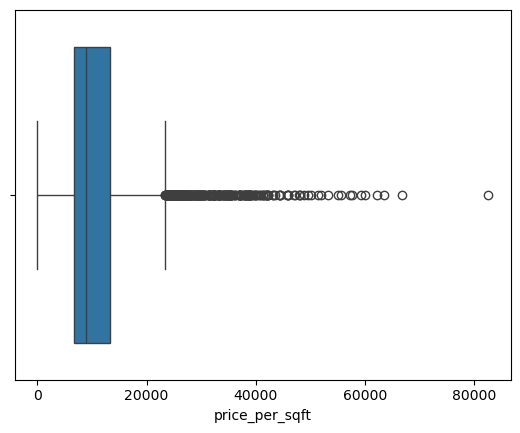

In [21]:
sns.boxplot(x=df['price_per_sqft'])

**BEDROOM**

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

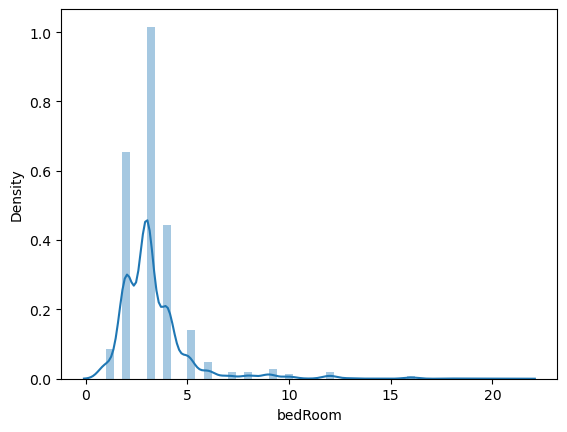

In [22]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

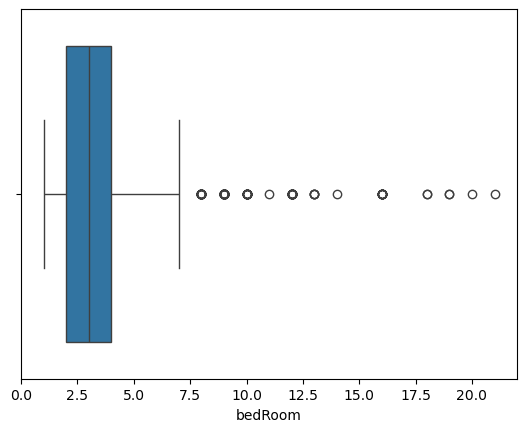

In [23]:
sns.boxplot(x=df['bedRoom'])

In [24]:
df[df['bedRoom']>10].sort_values('bedRoom',ascending=True)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1165,house,independent,sector 43,2.25,7500.0,3000.0,Plot area 550(51.1 sq.m.)Built Up area: 3000 s...,11,11,3+,5.0,West,New Property,NaN,3000.0,NaN,0,0,0,0,1,2,28
1946,house,independent,sector 43,3.00,5974.0,5022.0,Plot area 62(51.84 sq.m.),12,12,3+,5.0,West,New Property,NaN,558.0,NaN,0,0,0,0,1,2,20
2511,house,independent,sector 43,7.50,38760.0,1935.0,Plot area 215(179.77 sq.m.),12,12,3+,4.0,East,New Property,NaN,1935.0,NaN,1,1,1,1,0,1,72
2305,house,independent,sector 46,6.81,36911.0,1845.0,Plot area 205(171.41 sq.m.),12,14,3+,NaN,East,New Property,NaN,1845.0,NaN,0,1,0,0,1,1,40
2301,house,independent,sector 27,8.25,45833.0,1800.0,Plot area 210(175.59 sq.m.)Built Up area: 205 ...,12,12,3+,4.0,East,New Property,NaN,205.0,200.0,0,1,0,1,0,1,40
2290,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,1,99
2734,house,dlf city phase 1,sector 26,9.25,47804.0,1935.0,Plot area 1935(179.77 sq.m.)Built Up area: 700...,12,12,3+,4.0,North-East,New Property,NaN,7000.0,NaN,0,1,0,1,0,1,43
2758,house,floor wise designer kothi,sector 25,13.00,48148.0,2700.0,Plot area 300(250.84 sq.m.),12,16,3+,4.0,North-East,New Property,NaN,2700.0,NaN,1,1,1,1,0,1,144
2082,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,4.0,North-East,Relatively New,NaN,300.0,270.0,0,1,0,1,0,1,72
2850,house,dlf city plots phase 2,sector 25,10.00,44444.0,2250.0,Plot area 250(23.23 sq.m.),12,12,3+,4.0,North,Relatively New,NaN,250.0,NaN,1,1,0,0,0,1,114


In [25]:
df=df[df['bedRoom']<10]

In [26]:
df.shape

(3731, 23)

**BATHROOM**

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

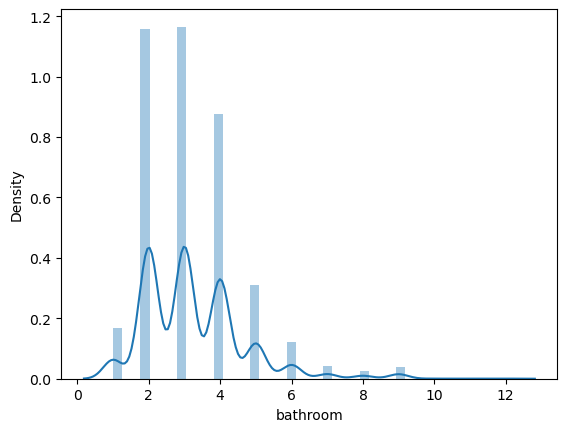

In [27]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

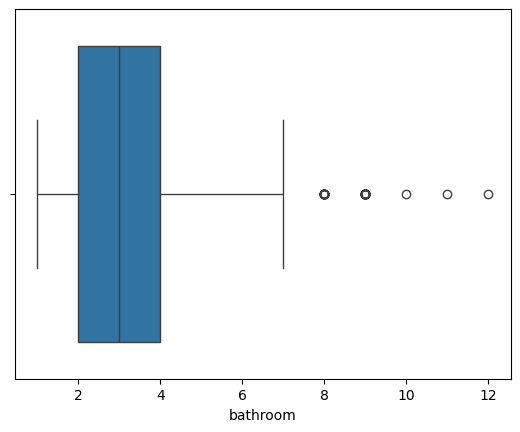

In [28]:
sns.boxplot(x=df['bathroom'])

In [29]:
df[df['bathroom'] > 8]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
74,house,independent,sector 25,7.60,38756.0,1961.0,Plot area 215(179.77 sq.m.),9,9,3,4.0,East,Relatively New,NaN,1935.0,NaN,1,0,1,1,0,1,84
309,house,independent,sector 40,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,3.0,North-West,Moderately Old,NaN,2367.0,NaN,0,1,1,0,0,1,83
323,house,anamika enclave,sector 12,6.00,14492.0,4140.0,Plot area 4140(384.62 sq.m.)Built Up area: 900...,9,9,3+,3.0,North-West,Old Property,NaN,9000.0,NaN,0,0,0,0,0,0,9
343,house,sector 38 rwa,sector 38,4.30,28782.0,1494.0,Plot area 166(138.8 sq.m.)Built Up area: 165 s...,9,9,3+,3.0,East,Relatively New,NaN,165.0,164.0,0,0,0,1,1,1,41
426,house,independent,sector 26,18.25,18250.0,10000.0,Plot area 550(51.1 sq.m.)Carpet area: 10000 sq...,7,9,3+,4.0,East,Relatively New,NaN,NaN,10000.0,1,1,1,1,0,1,77
540,house,independent,sector 45,4.49,24455.0,1836.0,Plot area 204(170.57 sq.m.),9,9,3+,3.0,North-West,Moderately Old,NaN,1836.0,NaN,0,0,0,0,1,1,90
545,house,independent,sector 24,10.00,25543.0,3915.0,Carpet area: 435 (40.41 sq.m.),8,10,3+,1.0,West,Undefined,NaN,NaN,435.0,0,0,0,0,0,0,0
668,house,independent,sector 2,3.65,23442.0,1557.0,Plot area 173(144.65 sq.m.),9,9,3+,3.0,West,New Property,NaN,1557.0,NaN,0,1,0,1,0,1,116
813,house,unitech greenwood city,sector 45,NaN,NaN,NaN,Plot area 240(200.67 sq.m.),9,9,3+,3.0,South-East,Relatively New,NaN,240.0,NaN,1,1,0,0,0,2,110
821,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,2,74


/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

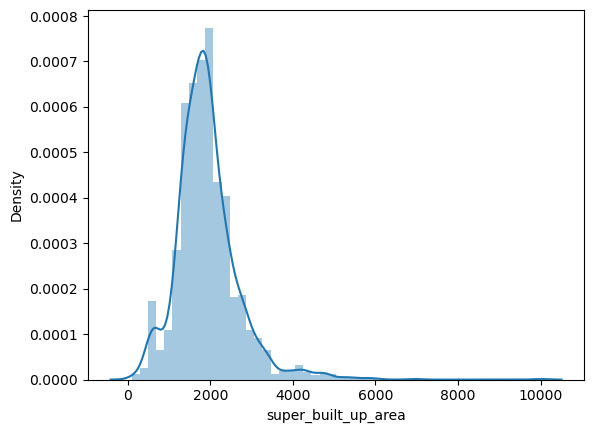

In [30]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

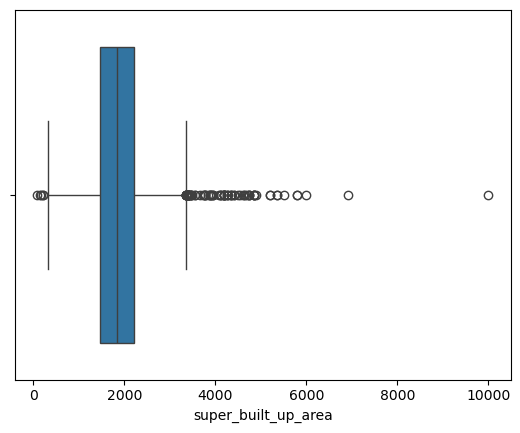

In [31]:
sns.boxplot(x=df['super_built_up_area'])

In [32]:
df['super_built_up_area'].describe()

count     1915.000000
mean      1921.658251
std        767.160169
min         89.000000
25%       1457.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [33]:
df[(df['super_built_up_area'] < 1000) | (df['super_built_up_area'] > 6000)].sort_values('super_built_up_area',ascending=True)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
881,flat,godrej aria,sector 79,1.10,11482.0,958.0,Super Built up area 89,2,2,3,9.0,NaN,New Property,89.0,NaN,NaN,0,0,0,0,0,0,62
613,flat,godrej nature plus,sector 33,1.40,15124.0,926.0,Super Built up area 145Carpet area: 86 sq.m.,3,2,3+,20.0,NaN,New Property,145.0,NaN,86.0,0,0,0,0,0,0,70
1060,flat,godrej oasis,sector 88a,1.45,8367.0,1733.0,Super Built up area 161Carpet area: 108.4 sq.m.,2,2,3+,9.0,NaN,Relatively New,161.0,NaN,108.4,1,0,0,0,0,2,85
347,flat,sushant lok 1 builder floors,sector 43,2.50,12920.0,1935.0,Super Built up area 215(179.77 sq.m.),3,3,2,2.0,NaN,New Property,215.0,NaN,NaN,0,0,0,0,0,0,0
1860,flat,unitech greenwood city,sector 45,2.40,12346.0,1944.0,Super Built up area 216(180.6 sq.m.),3,3,2,1.0,North-West,New Property,216.0,NaN,NaN,0,1,0,0,0,1,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,flat,ramsons kshitij,sector 95,0.45,4591.0,980.0,Super Built up area 980(91.04 sq.m.),2,2,1,2.0,NaN,Relatively New,980.0,NaN,NaN,1,0,0,0,0,0,89
2296,flat,sidhartha ncr greens,sector 95,0.56,5656.0,990.0,Super Built up area 990(91.97 sq.m.),2,2,3,13.0,NaN,New Property,990.0,NaN,NaN,0,0,0,0,0,0,8
2642,flat,afnhb jalvayu vihar,sector 30,0.69,7272.0,949.0,Super Built up area 990(91.97 sq.m.),2,2,1,3.0,North-East,Old Property,990.0,NaN,NaN,0,0,0,0,0,0,65
1323,flat,bestech park view grand spa,sector 81,4.70,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,1,140


In [34]:
df.loc[df['super_built_up_area'] < 500, ['area', 'super_built_up_area']]

,area,super_built_up_area
347,1935.0,215.0
613,926.0,145.0
718,431.0,431.0
881,958.0,89.0
983,400.0,406.0
1060,1733.0,161.0
1377,351.0,352.0
1632,339.0,439.0
1860,1944.0,216.0
2247,396.0,325.0


In [35]:
df.shape

(3731, 23)

In [36]:
target_indices = [347, 613, 718, 881, 983, 1060, 1377, 1632, 1860, 2247, 2520, 2554, 2897, 2901, 3575]

# 1. Create a condition for the difference being greater than 150
diff_condition = abs(df['area'] - df['super_built_up_area']) > 150

# 2. Create a condition to ensure the row's index is in our target list
index_condition = df.index.isin(target_indices)

# 3. Use .loc with both conditions combined using the '&' (AND) operator
df.loc[diff_condition & index_condition, 'super_built_up_area'] = df['area']

In [37]:
df.shape

(3731, 23)

In [38]:
df.loc[df['super_built_up_area'] < 500, ['area', 'super_built_up_area']]

,area,super_built_up_area
718,431.0,431.0
983,400.0,406.0
1377,351.0,352.0
1632,339.0,439.0
2247,396.0,325.0
2520,340.0,340.0
2554,357.0,414.0
2897,380.0,380.0
2901,465.0,465.0
3575,417.0,417.0


In [39]:
df[df['super_built_up_area'] >6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1323,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,1,140
3265,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49


**BUILT UP AREA**

In [40]:
df.shape

(3731, 23)

In [41]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1962,flat,bestech park view sanskruti,sector 92,1.55,7769.0,1995.0,Super Built up area 1995(185.34 sq.m.),3,4,3,8.0,North,Relatively New,1995.0,NaN,NaN,0,1,0,0,0,0,49
1301,house,independent,sector 8,0.59,10085.0,585.0,Plot area 585(54.35 sq.m.),2,2,2,2.0,NaN,Moderately Old,NaN,585.0,NaN,0,0,0,0,1,0,7
458,flat,tulip violet,sector 69,1.38,8966.0,1539.0,Super Built up area 1538(142.88 sq.m.),3,3,1,12.0,West,Relatively New,1538.0,NaN,NaN,0,0,0,1,0,0,86
141,flat,m3m soulitude,sector 89,1.30,8700.0,1494.0,Super Built up area 1500(139.35 sq.m.)Carpet a...,3,3,2,1.0,NaN,New Property,1500.0,NaN,900.0,0,0,0,0,1,0,45
787,flat,paras quartier,gwal pahari,5.90,11028.0,5350.0,Built Up area: 5350 (497.03 sq.m.),4,4,3+,0.0,NaN,Moderately Old,NaN,5350.0,NaN,0,0,0,0,0,0,63


/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/741828904.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'], kde=True)


<Axes: xlabel='carpet_area', ylabel='Density'>

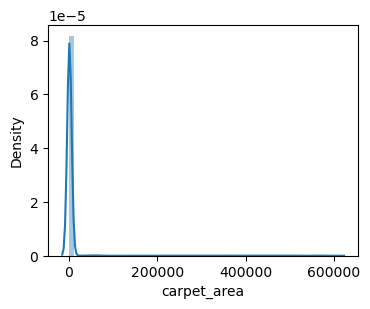

In [42]:
plt.figure(figsize=(4,3))
sns.distplot(df['carpet_area'], kde=True)


<Axes: xlabel='carpet_area'>

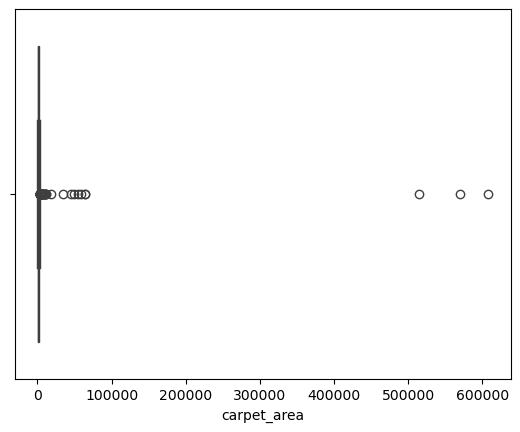

In [43]:
sns.boxplot(x=df['carpet_area'])

In [44]:
df[df['carpet_area']>10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,15
115,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1,0,0,0,0,0,37
818,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,1,0,1,60
1123,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.0,0,0,0,0,0,0,51
1638,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44
1796,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.0,1,0,0,0,0,0,15
2111,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76
2131,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,1,1,1,44
2342,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
2356,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0,0,0,0,0,0,37


In [45]:
df.drop([2, 115, 1123, 1638, 1796, 2111, 2356, 2503, 2651,
       3649],inplace=True)

In [46]:
df.shape

(3721, 23)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

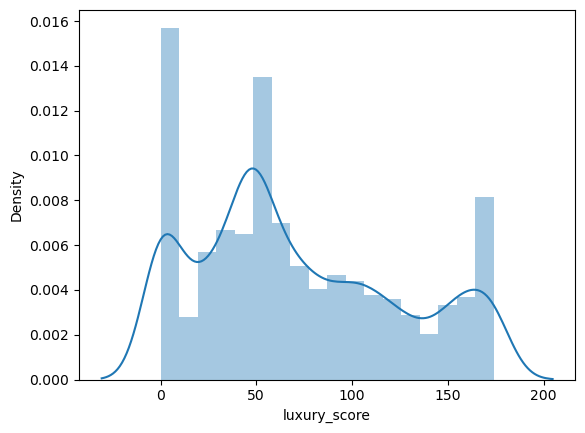

In [47]:
sns.distplot(df['luxury_score'])

<Axes: xlabel='luxury_score'>

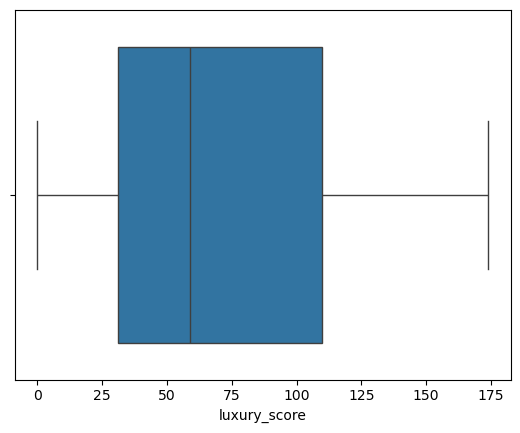

In [48]:
sns.boxplot(x=df['luxury_score'])

In [49]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/3889033217.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

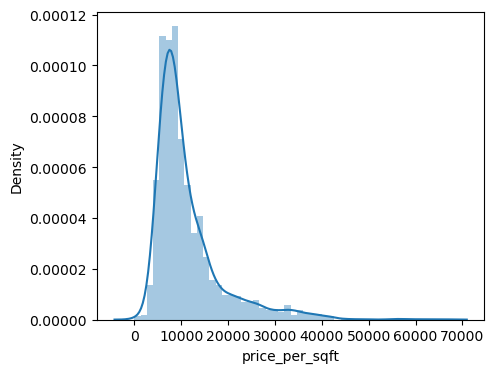

In [50]:
plt.figure(figsize=(5,4))
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

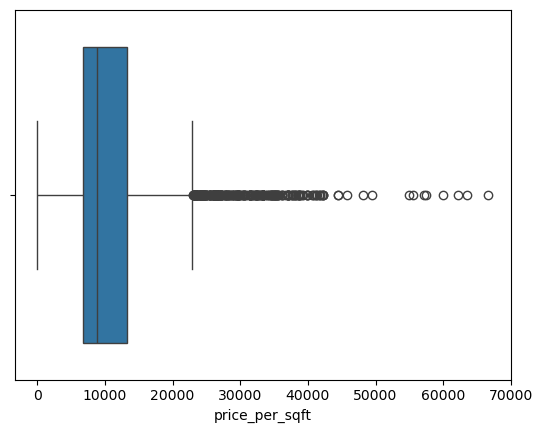

In [51]:
sns.boxplot(x=df['price_per_sqft'])

In [52]:
x = df[df['price_per_sqft']<=20000]

In [53]:
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(259.825)

In [54]:
x = df[(df['area']/df['bedRoom'])<259]

In [55]:
x['price_ratio'] = x['area']/x['bedRoom']

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/3915545810.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['price_ratio'] = x['area']/x['bedRoom']


In [56]:
x.to_excel("output.xlsx", index=False, header=True)

In [57]:
df.sample(3)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
520,flat,indiabulls centrum park,sector 103,2.20,7652.0,2875.0,Super Built up area 2875(267.1 sq.m.),4,6,3+,4.0,North-East,Relatively New,2875.0,NaN,NaN,0,1,0,0,0,1,108
261,flat,m3m heights,sector 65,2.65,18493.0,1433.0,Super Built up area 1433(133.13 sq.m.),2,2,3,4.0,North-East,New Property,1433.0,NaN,NaN,1,0,0,0,0,0,38
1953,house,not applicable,sector 4,0.51,14167.0,360.0,Plot area 40(33.45 sq.m.),4,4,3,4.0,NaN,New Property,NaN,360.0,NaN,0,0,0,0,0,0,0


In [58]:
df['price_area_ratio'] = df['area']/df['bedRoom']

In [59]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,price_area_ratio
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8,360.333333
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38,552.500000


In [60]:
df[df['price_area_ratio']<250].shape

(180, 24)

In [61]:
#Removing all the datas whose area to bedroom ratio is less than 100
df = df[df['price_area_ratio']>100]

In [62]:
df.shape

(3685, 24)

In [63]:
outlier_br = df[(df['price_area_ratio'] < 250) & (df['bedRoom']>3)]

In [64]:
outlier_br['bedRoom'] = round(outlier_br['bedRoom']/outlier_br['floorNum'])

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_2670/1464824049.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_br['bedRoom'] = round(outlier_br['bedRoom']/outlier_br['floorNum'])


In [65]:
df.update(outlier_br)

In [66]:
df['price_area_ratio'] = df['area']/df['bedRoom']

In [68]:
df[(df['price_area_ratio'] < 250) & (df['bedRoom'] > 4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,price_area_ratio
93,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,150.000000
387,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,1.0,NaN,Undefined,NaN,NaN,1000.0,0,0,0,0,0,0,0,166.666667
1106,house,independent,sector 5,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,1.0,NaN,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,180.000000
1206,house,independent,sector 7,1.16,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5,4,2,1.0,North-East,Undefined,NaN,NaN,110.0,0,0,0,0,0,0,0,198.000000
1747,house,independent,sector 12,2.50,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,1.0,South-East,Old Property,NaN,1800.0,NaN,0,0,0,1,0,0,8,200.000000
1939,house,independent,manesar,1.10,6173.0,1782.0,Plot area 1782(165.55 sq.m.),8,8,0,1.0,NaN,New Property,NaN,1782.0,NaN,0,0,0,0,0,0,0,222.750000
2806,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9,4,3,1.0,South,Undefined,NaN,NaN,120.0,0,0,0,0,0,0,0,120.000000
3148,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,Old Property,NaN,67.0,NaN,0,0,0,1,0,0,29,120.600000
3246,house,independent,manesar,0.80,6667.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,1.0,NaN,Relatively New,NaN,1200.0,NaN,0,0,0,0,0,0,0,150.000000
3329,house,independent,sector 5,1.10,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5,4,2,1.0,East,Undefined,NaN,1100.0,900.0,0,0,0,0,0,0,0,220.000000


In [70]:
df = df[~((df['price_area_ratio'] < 250) & (df['bedRoom'] > 4))]

In [72]:
df.to_csv('gurgaon_properties_outliers_done.csv',index=False)

In [73]:
df.shape

(3674, 24)